# Theory Notebook I: Kinetic Plasma Dynamics and the Vlasov Equation

**Physics II — Computation Project (Vlasov Track)**
*Theory Notebook · Report 1 of 2*

---

> *"The purpose of models is not to fit the data but to sharpen the questions."*
> — Samuel Karlin

---

## Abstract

This notebook develops the complete theoretical foundation required to simulate a neutral plasma and verify the existence of Langmuir waves. The exposition proceeds from first principles: beginning with the statistical description of a many-body charged system, establishing the geometric invariant that governs collisionless dynamics (Liouville's Theorem), deriving the self-consistent Vlasov–Poisson system, and culminating in a rigorous linearisation that yields the Bohm–Gross dispersion relation for Langmuir waves. Each section pairs a physical analogy with a complete mathematical derivation, and every symbol is anatomised on first appearance. The central role of **charge neutrality** as both a physical prerequisite and a dynamical restoring mechanism is addressed explicitly throughout.


In [1]:
# ── Standard imports for symbolic and numerical support ──────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.special import wofz          # Faddeeva / plasma dispersion function
from scipy.integrate import quad

# Notebook display settings
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'font.family': 'serif',
    'text.usetex': False,               # set True if LaTeX installed
    'legend.fontsize': 11,
})

print("Environment ready.")


Environment ready.


---
## §0 · The Fourth State: Defining the Plasma Medium

### Physical Narrative

A plasma is a gas heated beyond the ionisation threshold, such that electrons are liberated from their parent nuclei to form a coexisting population of free charges. Unlike a neutral gas — whose constituents interact only upon direct collision — every particle in a plasma participates in the collective electromagnetic "mood" of the entire system. The distinction is not merely quantitative.

> **Analogy.** A conventional gas is a crowded room of blindfolded strangers: they interact only when they physically collide. A plasma is the same room populated by people carrying permanent magnets — each individual exerts a force on every other, simultaneously and at a distance, without contact. The collective tension of these long-range interactions is what makes plasma physics a discipline unto itself.

### The Plasma Parameter and Debye Shielding

The criterion for a gas to behave as a plasma — and, critically, for the collisionless Vlasov description to be valid — is encapsulated in the **plasma parameter**:

$$\Lambda = n \lambda_D^3 \gg 1$$

| Symbol | Name | Physical meaning |
|---|---|---|
| $n$ | Number density | Particles per unit volume ($\text{m}^{-3}$) |
| $\lambda_D$ | Debye length | Screening length over which a test charge's Coulomb field is neutralised by surrounding charges |
| $\Lambda$ | Plasma parameter | Mean number of particles inside a Debye sphere |

The **Debye length** is derived from the requirement of electrostatic screening in thermal equilibrium:

$$\lambda_D = \sqrt{\frac{\varepsilon_0 k_B T_e}{n_0 e^2}}$$

The condition $\Lambda \gg 1$ is the *entrance examination* for Vlasov theory: it guarantees that collective electromagnetic forces — mediated by the mean field — overwhelmingly dominate over binary Coulomb collisions. When $\Lambda \gg 1$, the collision frequency $\nu_{ei} \sim \omega_{pe}/\Lambda$ is negligibly small compared to the plasma frequency, and the collisionless approximation is self-consistent.

### The Neutral Plasma: Quasineutrality

The simulation medium is specified as a **neutral plasma**, and this constraint is foundational rather than incidental. Quasineutrality requires that on scales $\ell \gg \lambda_D$, the net charge density vanishes:

$$\sum_\alpha q_\alpha n_\alpha \approx 0 \implies n_e \approx n_i \equiv n_0$$

In the standard electron–ion model adopted for Langmuir wave simulation, the ions are treated as a **static, uniform neutralising background** of density $n_0$. This is justified by the large mass ratio ($m_i/m_e \geq 1836$): on the fast timescales of electron plasma oscillations ($\omega \sim \omega_{pe}$), ion inertia renders them effectively immovable. Neutrality thus performs three indispensable roles:

1. **Eliminates the equilibrium electric field.** Without $n_e = n_i$, the unperturbed plasma would carry a net charge, driving a large-scale $\mathbf{E}_0 \neq 0$ that would continuously accelerate all electrons — destroying any possibility of a stable equilibrium $f_0$.

2. **Defines the equilibrium.** With $n_e = n_i = n_0$ and $\mathbf{E}_0 = 0$, Poisson's equation is trivially satisfied at zeroth order: $\nabla^2 \phi_0 = 0$, confirming $\phi_0 = 0$.

3. **Supplies the restoring force for Langmuir waves.** Any local electron compression or rarefaction breaks quasineutrality, instantly generating a restoring $\mathbf{E}_1$ via Poisson's equation. It is this electrostatic spring — present *only because* of the background neutrality — that drives plasma oscillations. The ion background is not inert scenery; it is the spring constant.


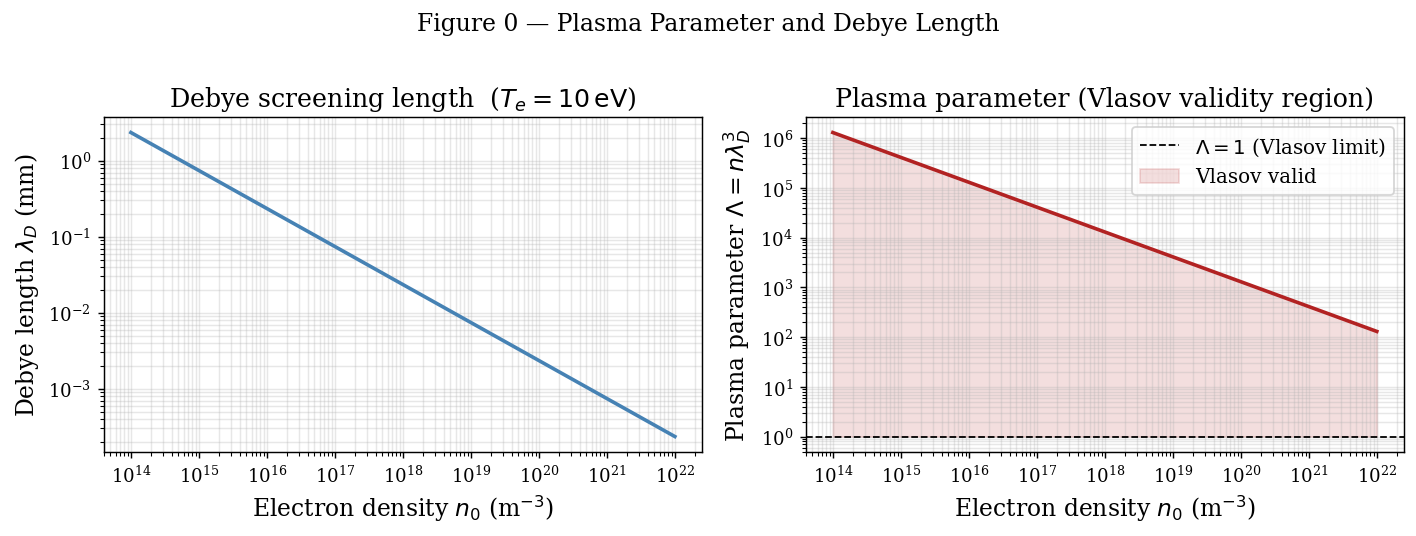

At n=1e18 m⁻³, Te=10 eV:
  Debye length  λ_D = 23.51 μm
  Plasma param  Λ   = 1.30e+04  >> 1  ✓


In [2]:
# ── §0 · Debye length and plasma parameter as functions of density ────────────
eps0 = 8.854e-12   # F/m
kB   = 1.381e-23   # J/K
e    = 1.602e-19   # C
me   = 9.109e-31   # kg

Te   = 10 * 11600  # 10 eV in Kelvin
n_vals = np.logspace(14, 22, 400)  # m^-3, covers lab to fusion plasmas

lambda_D = np.sqrt(eps0 * kB * Te / (n_vals * e**2))
Lambda   = n_vals * lambda_D**3

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.loglog(n_vals, lambda_D * 1e3, color='steelblue', lw=2)
ax1.set_xlabel(r'Electron density $n_0$ (m$^{-3}$)')
ax1.set_ylabel(r'Debye length $\lambda_D$ (mm)')
ax1.set_title(r'Debye screening length  ($T_e = 10\,\mathrm{eV}$)')
ax1.grid(True, which='both', alpha=0.3)

ax2.loglog(n_vals, Lambda, color='firebrick', lw=2)
ax2.axhline(1, ls='--', color='k', lw=1, label=r'$\Lambda = 1$ (Vlasov limit)')
ax2.fill_between(n_vals, 1, Lambda, where=Lambda > 1,
                 alpha=0.15, color='firebrick', label='Vlasov valid')
ax2.set_xlabel(r'Electron density $n_0$ (m$^{-3}$)')
ax2.set_ylabel(r'Plasma parameter $\Lambda = n\lambda_D^3$')
ax2.set_title(r'Plasma parameter (Vlasov validity region)')
ax2.legend()
ax2.grid(True, which='both', alpha=0.3)

plt.suptitle('Figure 0 — Plasma Parameter and Debye Length', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"At n=1e18 m⁻³, Te=10 eV:")
n_ex = 1e18
lD_ex = np.sqrt(eps0 * kB * Te / (n_ex * e**2))
L_ex  = n_ex * lD_ex**3
print(f"  Debye length  λ_D = {lD_ex*1e6:.2f} μm")
print(f"  Plasma param  Λ   = {L_ex:.2e}  >> 1  ✓")


---
## §I · Mapping the Mist: The Six-Dimensional Phase Space Distribution

### Physical Narrative

The defining challenge of plasma kinetics is statistical: a macroscopic plasma contains $\sim 10^{20}$ particles, making individual Newtonian tracking computationally and conceptually impossible. The resolution is to abandon the trajectory of each particle in favour of a **density map** over the six-dimensional phase space $\Gamma = \{\mathbf{r}, \mathbf{v}\}$.

> **Analogy.** Consider a busy international airport. Rather than tracking the trajectory of every individual traveller, an airport operations team monitors a *density map*: how many passengers are in which terminal (position $\mathbf{r}$) and moving at what speed toward which gate (velocity $\mathbf{v}$). The map is enormously informative — crowd bottlenecks, average transit times, surge predictions — without requiring any knowledge of which individual is where.

### The Distribution Function

The fundamental object of kinetic theory is the **one-particle distribution function**:

$$dN = f(\mathbf{r}, \mathbf{v}, t)\, d^3\mathbf{r}\, d^3\mathbf{v}$$

| Symbol | Name | Units | Physical meaning |
|---|---|---|---|
| $f(\mathbf{r}, \mathbf{v}, t)$ | Distribution function | $\text{m}^{-6}\,\text{s}^3$ | Phase-space number density |
| $d^3\mathbf{r}$ | Position volume element | $\text{m}^3$ | Small spatial box around $\mathbf{r}$ |
| $d^3\mathbf{v}$ | Velocity volume element | $\text{m}^3\,\text{s}^{-3}$ | Small velocity box around $\mathbf{v}$ |
| $dN$ | Particle count | dimensionless | Particles in phase-space cell |

Macroscopic observables are recovered by integrating $f$ over velocity space:

$$n(\mathbf{r}, t) = \int f\, d^3v, \qquad \mathbf{u}(\mathbf{r},t) = \frac{1}{n}\int \mathbf{v}\, f\, d^3v, \qquad P(\mathbf{r},t) = m\int |\mathbf{v}-\mathbf{u}|^2 f\, d^3v$$

A crucial conceptual point: in phase space, $\mathbf{r}$, $\mathbf{v}$, and $t$ are treated as **independent variables**. This is a fundamental departure from Newtonian mechanics, where position and velocity are both dependent on time.

### The Maxwellian Equilibrium

For a plasma in thermal equilibrium at temperature $T_e$, the distribution function takes the **Maxwell–Boltzmann** form:

$$f_0(v) = n_0 \left(\frac{m_e}{2\pi k_B T_e}\right)^{3/2} \exp\!\left(-\frac{m_e v^2}{2 k_B T_e}\right)$$

This spatially uniform, isotropic distribution is the natural equilibrium of the Vlasov system; perturbations about it give rise to Langmuir waves.


C:\Users\PC\AppData\Local\Temp\ipykernel_15092\3036281005.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


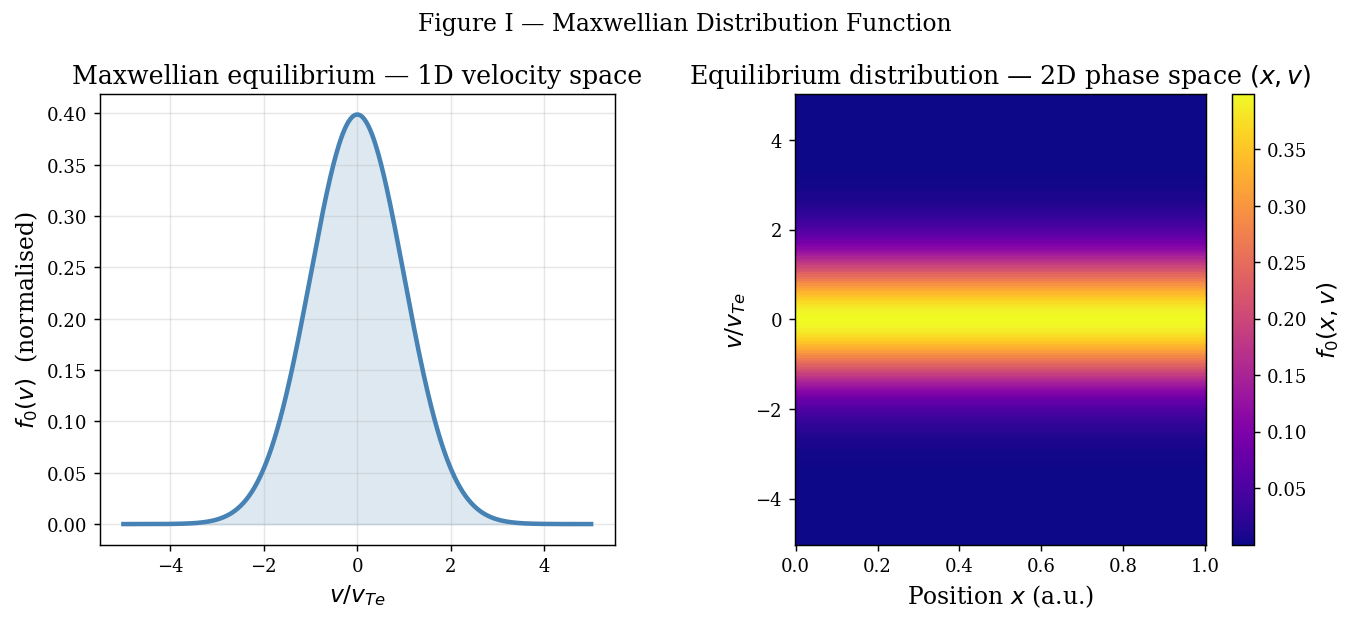

In [3]:
# ── §I · Maxwellian distribution in 1D and 2D phase space ────────────────────
vTe = 1.0   # thermal velocity (normalised)

v_1d = np.linspace(-5*vTe, 5*vTe, 500)
f_1d = np.exp(-v_1d**2 / (2*vTe**2)) / (np.sqrt(2*np.pi)*vTe)

# 2D phase space: x ∈ [0,1], v ∈ [-5,5] vTe  —  uniform in x for equilibrium
x_2d = np.linspace(0, 1, 200)
v_2d = np.linspace(-5*vTe, 5*vTe, 200)
VV, XX = np.meshgrid(v_2d, x_2d)
F_eq   = np.exp(-VV**2 / (2*vTe**2)) / (np.sqrt(2*np.pi)*vTe)   # uniform in x

fig = plt.figure(figsize=(12, 4.5))
gs  = gridspec.GridSpec(1, 2, wspace=0.35)

ax1 = fig.add_subplot(gs[0])
ax1.plot(v_1d/vTe, f_1d, color='steelblue', lw=2.5)
ax1.fill_between(v_1d/vTe, f_1d, alpha=0.18, color='steelblue')
ax1.set_xlabel(r'$v / v_{Te}$')
ax1.set_ylabel(r'$f_0(v)$  (normalised)')
ax1.set_title('Maxwellian equilibrium — 1D velocity space')
ax1.grid(alpha=0.3)

ax2 = fig.add_subplot(gs[1])
im = ax2.pcolormesh(x_2d, v_2d/vTe, F_eq.T, cmap='plasma', shading='auto')
plt.colorbar(im, ax=ax2, label=r'$f_0(x,v)$')
ax2.set_xlabel(r'Position $x$ (a.u.)')
ax2.set_ylabel(r'$v / v_{Te}$')
ax2.set_title('Equilibrium distribution — 2D phase space $(x,v)$')

plt.suptitle('Figure I — Maxwellian Distribution Function', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


---
## §II · The First-Principles Root: From Klimontovich to Vlasov

### Physical Narrative

We derive the Vlasov equation from the most microscopic possible starting point — an exact description of $N$ discrete point particles — and show how the smooth kinetic equation emerges by a controlled statistical coarse-graining.

> **Analogy.** Consider a digital photograph. Viewed at maximum zoom, the image resolves into discrete pixels of fixed colour values — the **Klimontovich picture**, exact and jagged. Zoom out sufficiently and the pixels blur into a smooth, continuous image — the **Vlasov picture**, approximate but tractable. The zoom level is controlled by the plasma parameter $\Lambda$.

### The Klimontovich Micro-Distribution

The exact microscopic state of $N_0$ identical particles of species $\alpha$ is captured by:

$$N_{\alpha}(\mathbf{x}, \mathbf{v}, t) = \sum_{k=1}^{N_0} \delta^3[\mathbf{x} - \mathbf{x}_k(t)]\, \delta^3[\mathbf{v} - \mathbf{v}_k(t)]$$

| Symbol | Meaning |
|---|---|
| $\delta^3[\,\cdot\,]$ | Three-dimensional Dirac delta — an infinitely sharp spike at the particle's exact coordinates |
| $\mathbf{x}_k(t),\, \mathbf{v}_k(t)$ | Exact position and velocity of particle $k$ at time $t$ |

Taking the total time derivative of $N_\alpha$ and applying the chain rule (since $\mathbf{x}_k$ and $\mathbf{v}_k$ are the independent variables through which time enters), one obtains the **Klimontovich equation** — an exact, noiseless statement of particle conservation at the microscopic level.

### The Mean-Field Limit: Ensemble Averaging

The smooth Vlasov distribution is recovered by an **ensemble average** over many statistically equivalent initial conditions:

$$f_\alpha(\mathbf{x}, \mathbf{v}, t) \equiv \langle N_\alpha(\mathbf{x}, \mathbf{v}, t) \rangle$$

This averaging procedure removes the discrete "noise" of individual particle correlations. The key approximation — the **mean-field limit** — is:

$$\langle N_\alpha \mathbf{E}_{\text{exact}} \rangle \approx f_\alpha \langle \mathbf{E} \rangle \equiv f_\alpha \mathbf{E}_{\text{mean}}$$

This factorisation assumes that the fluctuating micro-field of individual particles is uncorrelated with the distribution function itself. It is valid precisely when $\Lambda \gg 1$: binary correlations are suppressed by a factor $\sim 1/\Lambda$ relative to mean-field interactions. The Vlasov equation is thus the $\Lambda \to \infty$ limit of the BBGKY hierarchy.


---
## §III · The Geometry of Flow: Liouville's Theorem and Phase Space Incompressibility

### Physical Narrative

Before writing down the Vlasov equation in its final form, we must establish the geometric principle upon which it rests — a result so elegant that it requires no physical assumption beyond the Hamiltonian nature of charged-particle motion. This principle is **Liouville's Theorem**: the distribution function $f(\mathbf{r}, \mathbf{v}, t)$ behaves as an *incompressible fluid* in the six-dimensional phase space $\Gamma = (\mathbf{r}, \mathbf{v})$.

> **Analogy — The Water Bag.** Inject a drop of coloured dye into an incompressible fluid. The dye will stretch, fold, and deform into extraordinary filamentary structures as it is advected by the flow, but at no instant does its total *volume* decrease. You may elongate it into a ribbon, spiral it into a vortex, or fold it into a fractal — but you cannot compress it into a smaller droplet, nor allow it to diffuse away. The six-dimensional "mist" of phase space obeys the same constraint. Electromagnetic forces can shear and rotate the distribution into increasingly intricate structures, but they can never concentrate phase-space volume, nor cause it to expand. The phase-space density experienced by an observer *riding with the particles* is eternally constant.

This incompressibility is not a physical assumption — it is a **geometric consequence of Newton's Second Law** applied to a Hamiltonian system.

---

### Rigorous Mathematical Derivation

#### Step 1: The Phase-Space Fluid

Define the **six-dimensional state vector** and its time derivative:

$$\mathbf{w} = \begin{pmatrix} \mathbf{r} \\ \mathbf{v} \end{pmatrix} \in \mathbb{R}^6, \qquad \dot{\mathbf{w}} = \begin{pmatrix} \dot{\mathbf{r}} \\ \dot{\mathbf{v}} \end{pmatrix} = \begin{pmatrix} \mathbf{v} \\ \dfrac{q(\mathbf{E} + \mathbf{v}\times\mathbf{B})}{m} \end{pmatrix}$$

| Symbol | Name | Meaning |
|---|---|---|
| $\mathbf{w}$ | Phase-space position vector | Six-dimensional coordinate $(\mathbf{r}, \mathbf{v})$ |
| $\dot{\mathbf{r}} = \mathbf{v}$ | Spatial velocity | Rate of change of particle position |
| $\dot{\mathbf{v}}$ | Acceleration | Lorentz force per unit mass |
| $q,\, m$ | Charge, mass | Particle species parameters |
| $\mathbf{E},\, \mathbf{B}$ | Electric, magnetic fields | Self-consistent mean fields |

#### Step 2: The Six-Dimensional Divergence

Liouville's Theorem states that this phase-space flow field is **divergence-free**:

$$\nabla_{\mathbf{w}} \cdot \dot{\mathbf{w}} = \nabla_{\mathbf{r}} \cdot \dot{\mathbf{r}} + \nabla_{\mathbf{v}} \cdot \dot{\mathbf{v}} = 0$$

We verify each term:

**Term 1:** Since $\dot{\mathbf{r}} = \mathbf{v}$ and position $\mathbf{r}$ and velocity $\mathbf{v}$ are *independent coordinates* in phase space:

$$\nabla_{\mathbf{r}} \cdot \mathbf{v} = \frac{\partial v_x}{\partial x} + \frac{\partial v_y}{\partial y} + \frac{\partial v_z}{\partial z} = 0$$

**Term 2:** The Lorentz acceleration is $\dot{\mathbf{v}} = \frac{q}{m}(\mathbf{E} + \mathbf{v}\times\mathbf{B})$. Taking $\nabla_\mathbf{v}$:

- $\nabla_{\mathbf{v}} \cdot \mathbf{E} = 0$ because $\mathbf{E}$ depends on $\mathbf{r}$ and $t$, not $\mathbf{v}$.
- $\nabla_{\mathbf{v}} \cdot (\mathbf{v}\times\mathbf{B}) = \mathbf{B}\cdot(\underbrace{\nabla_\mathbf{v} \times \mathbf{v}}_{=\,0}) - \mathbf{v}\cdot(\underbrace{\nabla_\mathbf{v}\times\mathbf{B}}_{=\,0}) = 0$

since $\mathbf{B}$ is independent of $\mathbf{v}$.

Therefore, we arrive at the **fundamental result**:

$$\boxed{\nabla_{\mathbf{w}} \cdot \dot{\mathbf{w}} = 0}$$

The phase-space flow is genuinely incompressible.

#### Step 3: From Incompressibility to the Vlasov Equation

Particle conservation in $\Gamma$ is governed by the **continuity equation**:

$$\frac{\partial f}{\partial t} + \nabla_{\mathbf{w}} \cdot (f\, \dot{\mathbf{w}}) = 0$$

Expanding the divergence using the product rule:

$$\frac{\partial f}{\partial t} + \dot{\mathbf{w}} \cdot \nabla_{\mathbf{w}} f + f\underbrace{(\nabla_{\mathbf{w}} \cdot \dot{\mathbf{w}})}_{=\,0} = 0$$

The third term vanishes by Liouville's Theorem. The remaining two terms yield:

$$\frac{\partial f}{\partial t} + \mathbf{v}\cdot\nabla_{\mathbf{r}} f + \frac{q}{m}(\mathbf{E}+\mathbf{v}\times\mathbf{B})\cdot\nabla_{\mathbf{v}} f = 0$$

This is the **Vlasov equation** — the statement that $f$ is conserved along every particle trajectory in phase space:

$$\frac{df}{dt}\bigg|_{\text{along trajectory}} = 0$$

| Term | Physical meaning |
|---|---|
| $\partial f/\partial t$ | Local rate of change of phase-space density |
| $\mathbf{v}\cdot\nabla_\mathbf{r} f$ | **Free streaming**: particles carrying density from place to place |
| $\frac{q\mathbf{E}}{m}\cdot\nabla_\mathbf{v} f$ | **Field acceleration**: the electric force redistributes particles in velocity space |
| $\frac{q}{m}(\mathbf{v}\times\mathbf{B})\cdot\nabla_\mathbf{v} f$ | **Magnetic rotation**: rotates velocity-space distribution without doing work |

---

### Depth: Kinetic Entropy Conservation

Because $df/dt = 0$ along every trajectory, the **Boltzmann kinetic entropy**:

$$S_{\text{kin}} = -k_B \int f \ln f\, d^3r\, d^3v$$

is a rigorous constant of motion of the collisionless Vlasov system. The system never "forgets" its initial configuration, never spontaneously thermalises, and never relaxes toward the Maxwellian equilibrium. Fine-grained structure accumulates in velocity space without limit — a process visible in simulations as the progressive filamentation of $f$ in phase space, and the physical origin of Landau damping.

This is in stark contrast to the Boltzmann equation (which includes a collision operator $C[f]$ on the right-hand side) whose H-theorem guarantees $dS/dt \geq 0$. The Vlasov equation occupies the opposite extreme: **perfect time-reversibility** and **zero entropy production**.


<>:28: SyntaxWarning: invalid escape sequence '\,'
<>:28: SyntaxWarning: invalid escape sequence '\,'
C:\Users\PC\AppData\Local\Temp\ipykernel_15092\1269571603.py:28: SyntaxWarning: invalid escape sequence '\,'
  ax.set_title(f'$t = {t:.1f}\,\omega_{{pe}}^{{-1}}$')


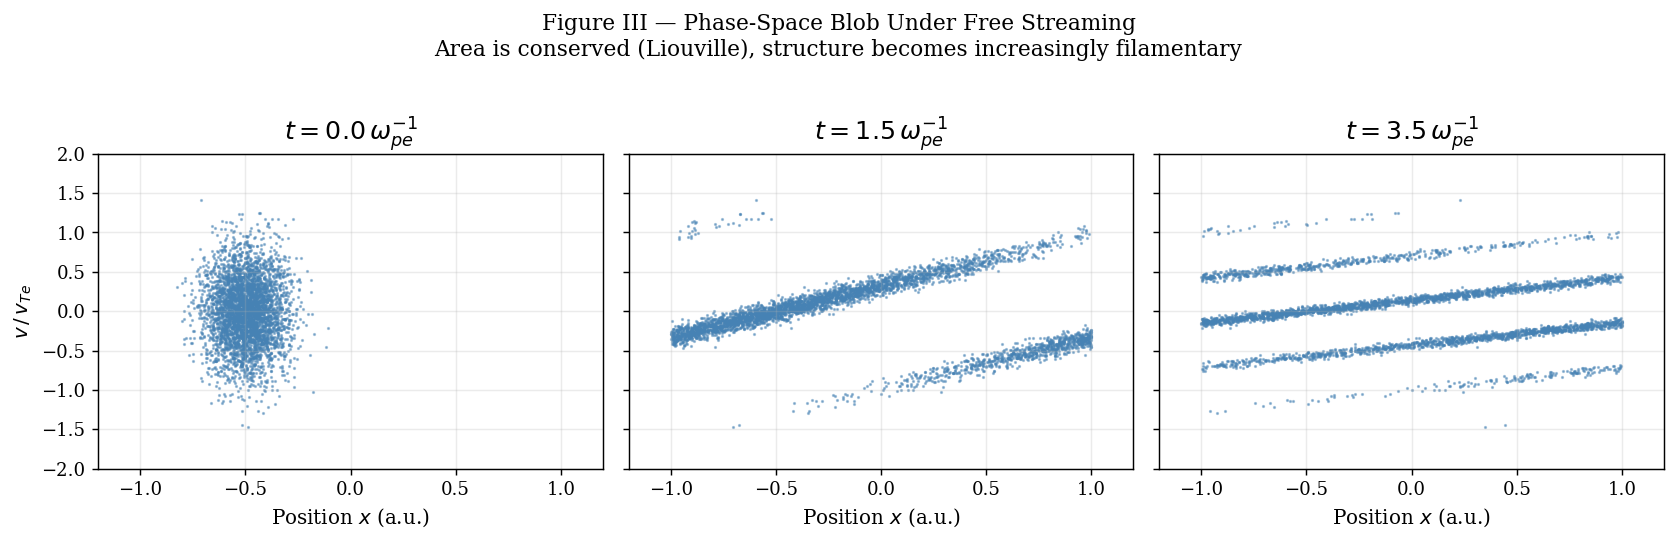

In [4]:
# ── §III · Visualising phase-space incompressibility: shearing of a phase blob ─
# We numerically advect an elliptical blob under the free-streaming map
# x(t) = x0 + v*t,  v(t) = v  (no forces), demonstrating area conservation.

from matplotlib.patches import Ellipse
from matplotlib.transforms import Affine2D

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharex=True, sharey=True)

vTe = 1.0
times = [0.0, 1.5, 3.5]

# Initial blob: Gaussian in (x,v) phase space
np.random.seed(42)
N_blob = 4000
x0_blob = np.random.normal(0.5, 0.1, N_blob)
v0_blob = np.random.normal(0.0, 0.4*vTe, N_blob)

for ax, t in zip(axes, times):
    # Free streaming: x -> x + v*t, v unchanged
    xt = x0_blob + v0_blob * t
    vt = v0_blob.copy()

    ax.scatter(xt % 2 - 1, vt/vTe, s=0.6, alpha=0.5, color='steelblue', rasterized=True)
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-2.0, 2.0)
    ax.set_xlabel(r'Position $x$ (a.u.)', fontsize=11)
    ax.set_title(f'$t = {t:.1f}\,\omega_{{pe}}^{{-1}}$')
    ax.grid(alpha=0.25)

axes[0].set_ylabel(r'$v\,/\,v_{Te}$', fontsize=11)
fig.suptitle(
    'Figure III — Phase-Space Blob Under Free Streaming\n'
    'Area is conserved (Liouville), structure becomes increasingly filamentary',
    fontsize=12, y=1.03
)
plt.tight_layout()
plt.show()


---
## §IV · The Self-Consistent Loop: The Vlasov–Poisson System

### Physical Narrative

The Vlasov equation alone is incomplete: it requires the electric field $\mathbf{E}$ as an input, but $\mathbf{E}$ itself depends on how the particles are distributed in space. This mutual dependence is the **self-consistent loop** at the heart of plasma dynamics.

> **Analogy — The Flash Mob.** A flash mob of dancers assembles in a public square. Their collective movement *creates* the music (the electromagnetic field) through some distributed speaker system, and that same music simultaneously instructs each dancer where to step next (the force on each particle). The choreography and the soundtrack are inseparable — each generates the other.

### The Vlasov–Poisson System

For a non-relativistic, unmagnetised ($\mathbf{B} = 0$) electron plasma with a stationary ion background $n_0$, the governing equations are:

**Vlasov equation (electrons):**

$$\frac{\partial f}{\partial t} + \mathbf{v}\cdot\nabla_{\mathbf{r}} f - \frac{e\mathbf{E}}{m_e}\cdot\nabla_{\mathbf{v}} f = 0$$

**Poisson's equation (electrostatics):**

$$-\varepsilon_0 \nabla^2 \phi = \rho = e(n_0 - n_e), \qquad \mathbf{E} = -\nabla\phi$$

**Charge density closure:**

$$n_e(\mathbf{r}, t) = \int f(\mathbf{r}, \mathbf{v}, t)\, d^3v$$

| Symbol | Name | Meaning |
|---|---|---|
| $e$ | Elementary charge | $1.602 \times 10^{-19}$ C (positive value; electron charge is $-e$) |
| $\phi(\mathbf{r},t)$ | Electrostatic potential | Scalar potential; $\mathbf{E} = -\nabla\phi$ |
| $\rho(\mathbf{r},t)$ | Charge density | $e(n_0 - n_e)$; zero in equilibrium |
| $n_0$ | Background ion density | Uniform, time-independent; enforces quasineutrality |
| $n_e$ | Electron number density | $\int f\,d^3v$; fluctuates with plasma dynamics |
| $\varepsilon_0$ | Permittivity of free space | $8.854\times 10^{-12}$ F m$^{-1}$ |

The loop closes as follows: $f$ determines $n_e$ by integration; $n_e$ enters Poisson's equation to determine $\phi$; $\phi$ generates $\mathbf{E}$; $\mathbf{E}$ enters the Vlasov equation to advance $f$.


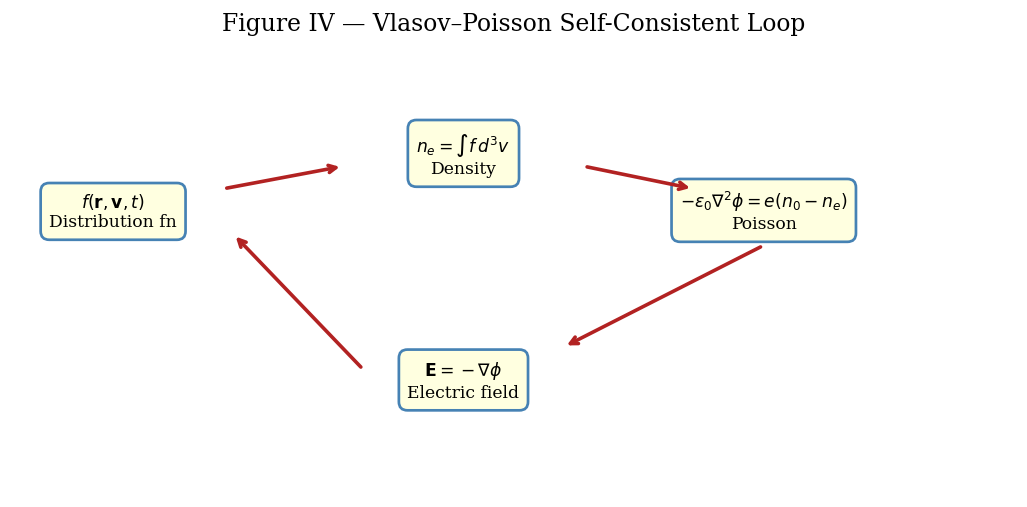

Self-consistent loop: f → nₑ → φ → E → f (closes the system)


In [5]:
# ── §IV · Schematic of the Vlasov–Poisson self-consistent loop ──────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.set_xlim(0, 10); ax.set_ylim(0, 4); ax.axis('off')
ax.set_title('Figure IV — Vlasov–Poisson Self-Consistent Loop', fontsize=13)

boxes = [
    (1.0, 2.5, r'$f(\mathbf{r},\mathbf{v},t)$'+"\nDistribution fn"),
    (4.5, 3.0, r'$n_e = \int f\,d^3v$'+"\nDensity"),
    (7.5, 2.5, r'$-\varepsilon_0\nabla^2\phi = e(n_0-n_e)$'+"\nPoisson"),
    (4.5, 1.0, r'$\mathbf{E}=-\nabla\phi$'+"\nElectric field"),
]
for (x, y, txt) in boxes:
    ax.text(x, y, txt, ha='center', va='center', fontsize=9.5,
            bbox=dict(boxstyle='round,pad=0.5', fc='lightyellow', ec='steelblue', lw=1.5))

arrows = [
    (2.1, 2.7, 3.3, 2.9),
    (5.7, 2.9, 6.8, 2.7),
    (7.5, 2.2, 5.5, 1.3),
    (3.5, 1.1, 2.2, 2.3),
]
for (x1,y1,x2,y2) in arrows:
    ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
                arrowprops=dict(arrowstyle='->', color='firebrick', lw=2))

plt.tight_layout()
plt.show()
print("Self-consistent loop: f → nₑ → φ → E → f (closes the system)")


---
## §V · The Plasma Shiver: Linearisation and the Derivation of Langmuir Waves

### Why a Neutral Plasma is the Required Medium (Revisited)

The linearisation procedure begins by identifying a stable **equilibrium** about which to perturb. For this equilibrium to exist, and for the perturbation analysis to be self-consistent, the medium must be a neutral plasma. As established in §0:

- The ion background $n_0$ ensures $\mathbf{E}_0 = 0$, so no equilibrium force acts on the electrons.
- Any small departure from neutrality $\delta n = n_0 - n_e \neq 0$ immediately generates a restoring $\mathbf{E}_1$ through Poisson's equation, acting as the spring that drives oscillations.
- Without neutrality, no equilibrium exists, and the concept of a small perturbation is meaningless.

### Physical Analogy

> **The Plucked Guitar String.** A guitar string at rest represents the equilibrium distribution $f_0(\mathbf{v})$ — a Maxwellian in velocity space, uniform in position, with zero electric field. Plucking the string imparts a small displacement — the perturbation $f_1(\mathbf{r},\mathbf{v},t)$. Linearisation is the act of studying *only the first, infinitesimal vibration* before the amplitude grows large enough that the string's restoring force becomes non-linear. The vibration frequency (the normal mode) is then a property of the string's tension (plasma density, $\omega_{pe}$) and its material stiffness (thermal velocity, $v_{Te}$), independent of the amplitude.

---

### Rigorous Mathematical Derivation

#### Step 1: The Linearisation Ansatz

Decompose $f$ and $\phi$ into equilibrium and perturbation:

$$f(\mathbf{r}, \mathbf{v}, t) = f_0(\mathbf{v}) + f_1(\mathbf{r}, \mathbf{v}, t), \qquad |f_1| \ll f_0$$

$$\phi(\mathbf{r}, t) = \underbrace{\phi_0}_{=\,0} + \phi_1(\mathbf{r}, t)$$

| Symbol | Name | Role |
|---|---|---|
| $f_0(\mathbf{v})$ | Equilibrium distribution | Maxwellian; depends on $\mathbf{v}$ only (spatial uniformity, no mean flow) |
| $f_1(\mathbf{r}, \mathbf{v}, t)$ | First-order perturbation | Small departure from equilibrium; carries the wave information |
| $\phi_1(\mathbf{r}, t)$ | Perturbed potential | Generated by $f_1$ through Poisson's equation |
| $|f_1| \ll f_0$ | Linearisation condition | Formal validity boundary: amplitude must remain small |

Substituting into the Vlasov equation and discarding all terms of order $\mathcal{O}(f_1 \phi_1)$ (i.e., products of two small quantities) yields the **linearised Vlasov equation**:

$$\frac{\partial f_1}{\partial t} + \mathbf{v}\cdot\nabla_{\mathbf{r}} f_1 - \frac{e}{m_e}\mathbf{E}_1\cdot\nabla_{\mathbf{v}} f_0 = 0$$

Note: the term $\frac{e\mathbf{E}_0}{m_e}\cdot\nabla_\mathbf{v} f_1$ vanishes identically since $\mathbf{E}_0 = 0$ in a neutral plasma. The term $\frac{e\mathbf{E}_1}{m_e}\cdot\nabla_\mathbf{v} f_1$ is second-order small and discarded. Only one term survives from the force contribution: the first-order field $\mathbf{E}_1$ acting on the *equilibrium gradient* $\nabla_\mathbf{v} f_0$.

The linearised Poisson equation is:

$$\varepsilon_0 k^2 \hat{\phi}_1 = e \int \hat{f}_1\, d^3v$$

#### Step 2: Fourier–Laplace Transform

Seek plane-wave (normal-mode) solutions:

$$f_1(\mathbf{r}, \mathbf{v}, t) = \hat{f}_1(\mathbf{v})\, e^{i(\mathbf{k}\cdot\mathbf{r} - \omega t)}, \qquad \phi_1(\mathbf{r}, t) = \hat{\phi}_1\, e^{i(\mathbf{k}\cdot\mathbf{r} - \omega t)}$$

| Symbol | Name | Meaning |
|---|---|---|
| $\mathbf{k}$ | Wave vector | Direction and wavenumber of propagation; $k = |\mathbf{k}| = 2\pi/\lambda$ |
| $\omega$ | Complex frequency | Real part: oscillation frequency; imaginary part: growth/damping rate |
| $\hat{f}_1(\mathbf{v})$ | Velocity-space amplitude | How the perturbation is distributed in velocity space |
| $\hat{\phi}_1$ | Potential amplitude | Scalar amplitude of the electrostatic wave |

Since $\mathbf{E}_1 = -\nabla\phi_1 = -i\mathbf{k}\hat{\phi}_1 e^{i(\mathbf{k}\cdot\mathbf{r}-\omega t)}$, substitution into the linearised Vlasov equation gives:

$$(-i\omega + i\mathbf{k}\cdot\mathbf{v})\hat{f}_1 = \frac{ie}{m_e}(\mathbf{k}\cdot\nabla_\mathbf{v} f_0)\hat{\phi}_1$$

Solving algebraically for $\hat{f}_1$:

$$\hat{f}_1(\mathbf{v}) = -\frac{e}{m_e}\frac{\mathbf{k}\cdot\nabla_\mathbf{v} f_0}{\omega - \mathbf{k}\cdot\mathbf{v}}\,\hat{\phi}_1$$

The **resonance denominator** $(\omega - \mathbf{k}\cdot\mathbf{v})$ is the most physically consequential factor in kinetic plasma theory. It vanishes when a particle's velocity component along $\mathbf{k}$ equals the wave phase velocity $v_\phi = \omega/k$ — the condition for **Landau resonance** and collisionless wave-particle energy exchange.

#### Step 3: The Dielectric Function

Substituting $\hat{f}_1$ into the linearised Poisson equation:

$$k^2\hat{\phi}_1 = \frac{e}{\varepsilon_0}\int \hat{f}_1\, d^3v = -\frac{e^2}{\varepsilon_0 m_e}\hat{\phi}_1 \int \frac{\mathbf{k}\cdot\nabla_\mathbf{v} f_0}{\omega - \mathbf{k}\cdot\mathbf{v}}\, d^3v$$

For a non-trivial wave ($\hat{\phi}_1 \neq 0$), the bracket must vanish. Restricting to the 1D case with propagation along $\hat{x}$ (so $v_\parallel \equiv v_x$), we integrate out the transverse Maxwellian components to obtain the **plasma dielectric function**:

$$\boxed{\varepsilon(\omega, k) = 1 - \frac{\omega_{pe}^2}{k^2}\int_{-\infty}^{\infty}\frac{\partial f_0/\partial v_\parallel}{\omega - k v_\parallel}\, dv_\parallel = 0}$$

| Symbol | Name | Meaning |
|---|---|---|
| $\varepsilon(\omega, k)$ | Longitudinal dielectric function | Plasma's frequency-dependent electrical susceptibility |
| $\omega_{pe}$ | Electron plasma frequency | $\omega_{pe} = \sqrt{n_0 e^2 / m_e \varepsilon_0}$ — natural oscillation frequency at $k=0$ |
| $\partial f_0/\partial v_\parallel$ | Velocity-space slope of $f_0$ | Governs Landau exchange; negative for Maxwellian at phase velocity |

#### Step 4: The Bohm–Gross Dispersion Relation

For a Maxwellian $f_0$ with thermal velocity $v_{Te} = \sqrt{k_B T_e/m_e}$, in the **long-wavelength limit** $k\lambda_D \ll 1$ (equivalently $kv_{Te}/\omega \ll 1$), expand the resonance denominator as a geometric series:

$$\frac{1}{\omega - kv} = \frac{1}{\omega}\sum_{n=0}^{\infty}\left(\frac{kv}{\omega}\right)^n$$

Substituting and integrating term-by-term using the Maxwellian moments $\langle v^0 \rangle = 1$, $\langle v^1 \rangle = 0$, $\langle v^2 \rangle = v_{Te}^2$:

$$\varepsilon(\omega,k) \approx 1 - \frac{\omega_{pe}^2}{\omega^2}\left(1 + \frac{3k^2 v_{Te}^2}{\omega^2} + \cdots\right) = 0$$

Solving for $\omega^2$ to leading order in $(k\lambda_D)^2$:

$$\boxed{\omega^2 = \omega_{pe}^2 + 3k^2 v_{Te}^2}$$

This is the **Bohm–Gross dispersion relation** for Langmuir waves.

| Symbol | Name | Physical role |
|---|---|---|
| $\omega$ | Wave frequency | Observable; measured in simulation by Fourier analysis of $E_1(t)$ |
| $\omega_{pe} = \sqrt{n_0 e^2 / m_e\varepsilon_0}$ | Plasma frequency | Sets the low-$k$ cutoff; depends only on *density* $n_0$ |
| $k = 2\pi/\lambda$ | Wavenumber | Spatial frequency; inverse of wavelength $\lambda$ |
| $v_{Te} = \sqrt{k_B T_e / m_e}$ | Thermal velocity | Temperature-dependent stiffening coefficient |
| Coefficient $3$ | Adiabatic index | From $\langle v_\parallel^2 \rangle = v_{Te}^2$ for a 1D Maxwellian |

**Physical interpretation:** The dispersion relation has two additive contributions. The first, $\omega_{pe}^2$, is purely inertial — it is the frequency at which a cold, pressureless electron slab would oscillate against the ion background. The second, $3k^2 v_{Te}^2$, is a thermal correction: finite temperature endows the electrons with a kinetic pressure, $P = n_0 m_e v_{Te}^2$, that allows perturbations to *propagate* as genuine waves rather than standing oscillations. In the cold limit ($T_e \to 0$), the relation degenerates to $\omega = \omega_{pe}$, a non-dispersive, non-propagating plasma oscillation.

---

### Depth: Landau Damping

The integral defining $\varepsilon(\omega, k)$ is singular along the real $\omega$-axis wherever $\omega = kv_\parallel$. Landau (1946) resolved this by treating $\omega$ as a complex frequency and analytically continuing the integral into the complex $v$-plane via the **Plemelj–Sokhotski formula**:

$$\lim_{\gamma \to 0^+}\frac{1}{\omega + i\gamma - kv} = \mathcal{P}\frac{1}{\omega - kv} + i\pi\delta(\omega - kv)$$

| Symbol | Meaning |
|---|---|
| $\mathcal{P}$ | Cauchy principal value integral |
| $\delta(\omega - kv)$ | Dirac delta — selects the resonant particles at $v = \omega/k$ |
| $\gamma = \text{Im}(\omega)$ | Growth/damping rate |

The imaginary part of $\varepsilon = 0$ then yields a **damping rate**:

$$\gamma = \text{Im}(\omega) = -\frac{\pi\omega_{pe}^3}{2k^2}\left.\frac{\partial f_0}{\partial v}\right|_{v=\omega/k}$$

For a Maxwellian, $\partial f_0/\partial v < 0$ at the phase velocity (since the phase velocity lies on the falling tail), so $\gamma < 0$: the wave is **damped without collisions**. The damping arises because there are slightly more particles moving slower than the wave than faster; the wave therefore loses more energy to particles it accelerates (from behind) than it gains from particles it decelerates (from in front). This mechanism is completely invisible to fluid (MHD) theory, which discards velocity-space structure entirely, and is therefore among the most profound predictions uniquely available to the Vlasov kinetic description.


Plasma frequency  ω_pe = 1.784e+10 rad/s
Thermal velocity  v_Te = 9.377e+05 m/s
Debye length      λ_D  = 3.717e-05 m


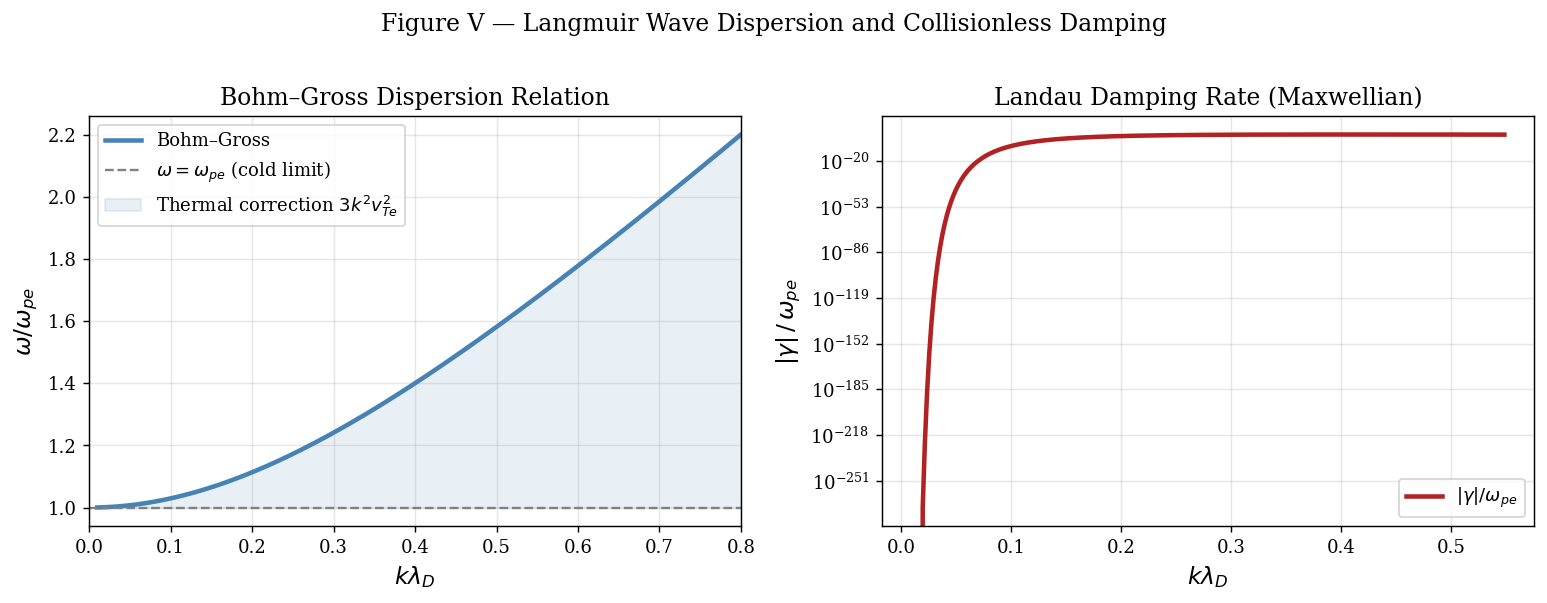

In [6]:
# ── §V · Bohm–Gross dispersion relation and Landau damping rate ──────────────
eps0 = 8.854e-12
kB   = 1.381e-23
e    = 1.602e-19
me   = 9.109e-31

# Plasma parameters
n0   = 1e17          # m^-3
Te   = 5 * 11600     # 5 eV
vTe  = np.sqrt(kB * Te / me)
wpe  = np.sqrt(n0 * e**2 / (me * eps0))
lD   = vTe / (wpe * np.sqrt(2))   # Debye length (approx)

print(f"Plasma frequency  ω_pe = {wpe:.3e} rad/s")
print(f"Thermal velocity  v_Te = {vTe:.3e} m/s")
print(f"Debye length      λ_D  = {lD:.3e} m")

# Wave numbers (normalised by Debye length)
k_lD = np.linspace(0.01, 0.8, 400)
k    = k_lD / lD

# Bohm–Gross dispersion relation
omega_BG = np.sqrt(wpe**2 + 3 * k**2 * vTe**2)

# Approximate Landau damping (Maxwellian, valid for k*lD << 1)
# γ/ω_pe ≈ -√(π/8) * (ω/k)^3/v_Te^3 * exp(-(ω/k)^2/(2v_Te^2))
v_ph   = omega_BG / k
xi     = v_ph / (np.sqrt(2)*vTe)
gamma  = -np.sqrt(np.pi/8) * (wpe**4 / (k**3 * vTe**3)) * np.exp(-xi**2)
gamma_norm = gamma / wpe

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Panel 1: Dispersion relation
ax1.plot(k_lD, omega_BG/wpe, color='steelblue', lw=2.5, label='Bohm–Gross')
ax1.axhline(1.0, ls='--', color='grey', lw=1.3, label=r'$\omega = \omega_{pe}$ (cold limit)')
ax1.fill_between(k_lD, 1.0, omega_BG/wpe, alpha=0.12, color='steelblue',
                 label='Thermal correction $3k^2v_{Te}^2$')
ax1.set_xlabel(r'$k\lambda_D$', fontsize=13)
ax1.set_ylabel(r'$\omega / \omega_{pe}$', fontsize=13)
ax1.set_title('Bohm–Gross Dispersion Relation', fontsize=13)
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)
ax1.set_xlim(0, 0.8)

# Panel 2: Landau damping rate
mask = k_lD < 0.55  # asymptotic formula valid region
ax2.semilogy(k_lD[mask], np.abs(gamma_norm[mask]),
             color='firebrick', lw=2.5, label=r'$|\gamma|/\omega_{pe}$')
ax2.set_xlabel(r'$k\lambda_D$', fontsize=13)
ax2.set_ylabel(r'$|\gamma|\,/\,\omega_{pe}$', fontsize=13)
ax2.set_title('Landau Damping Rate (Maxwellian)', fontsize=13)
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3, which='both')

plt.suptitle('Figure V — Langmuir Wave Dispersion and Collisionless Damping', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


---
## §VI · Implications for Numerical Simulation

### What Linear Theory Gives — and Does Not Give

The Bohm–Gross dispersion relation is an exact result of the *linearised* Vlasov–Poisson system. It is valid in the regime $|f_1| \ll f_0$. As the wave amplitude grows, several phenomena emerge that are invisible to linear theory:

| Regime | Physics | Linear theory |
|---|---|---|
| $|f_1|/f_0 \ll 1$ | Linear Langmuir waves, Landau damping | Complete and exact |
| $|f_1|/f_0 \sim 1$ | Particle trapping in wave troughs | Fails entirely |
| $|f_1|/f_0 > 1$ | Non-linear saturation, wave breaking | Inaccessible |

A full Vlasov simulation is required to capture the non-linear evolution.

### Why the Semi-Lagrangian Method is Preferred

For verification of Langmuir waves, the simulation must resolve fine-scale velocity-space structure (filaments generated by Liouville's Theorem) without introducing artificial noise. Two principal families of methods exist:

1. **Particle-in-Cell (PIC):** Represent $f$ by macro-particles. Each macro-particle introduces statistical noise $\sim 1/\sqrt{N_p}$, which can mask the small-amplitude Langmuir signal, especially the Landau-damped tail.

2. **Semi-Lagrangian (Eulerian Vlasov):** Represent $f$ on a fixed $(x,v)$ grid and advect it using the method of characteristics (Liouville's Theorem). This is **noise-free** and conserves phase-space volume exactly at the grid level.

The Semi-Lagrangian method is the preferred choice for this project because: (a) it preserves the entropy conservation of the Vlasov equation; (b) it resolves the Landau-damped signal without noise floor problems; and (c) it directly visualises the phase-space distribution, allowing comparison of filamentation against theory.

### Conservation Laws as Sanity Checks

The following quantities are **exact invariants** of the Vlasov–Poisson system and must be monitored as simulation diagnostics:

$$\mathcal{N} = \int f\, d^3r\, d^3v \quad \text{(total particle number)}$$

$$\mathcal{E} = \underbrace{\frac{m_e}{2}\int v^2 f\, d^3r\, d^3v}_{\text{kinetic}} + \underbrace{\frac{\varepsilon_0}{2}\int E^2\, d^3r}_{\text{field}} \quad \text{(total energy)}$$

$$\mathcal{P} = \int m_e \mathbf{v} f\, d^3r\, d^3v \quad \text{(total momentum)}$$

Deviation from conservation in the numerical solution is the primary indicator of numerical error.

---


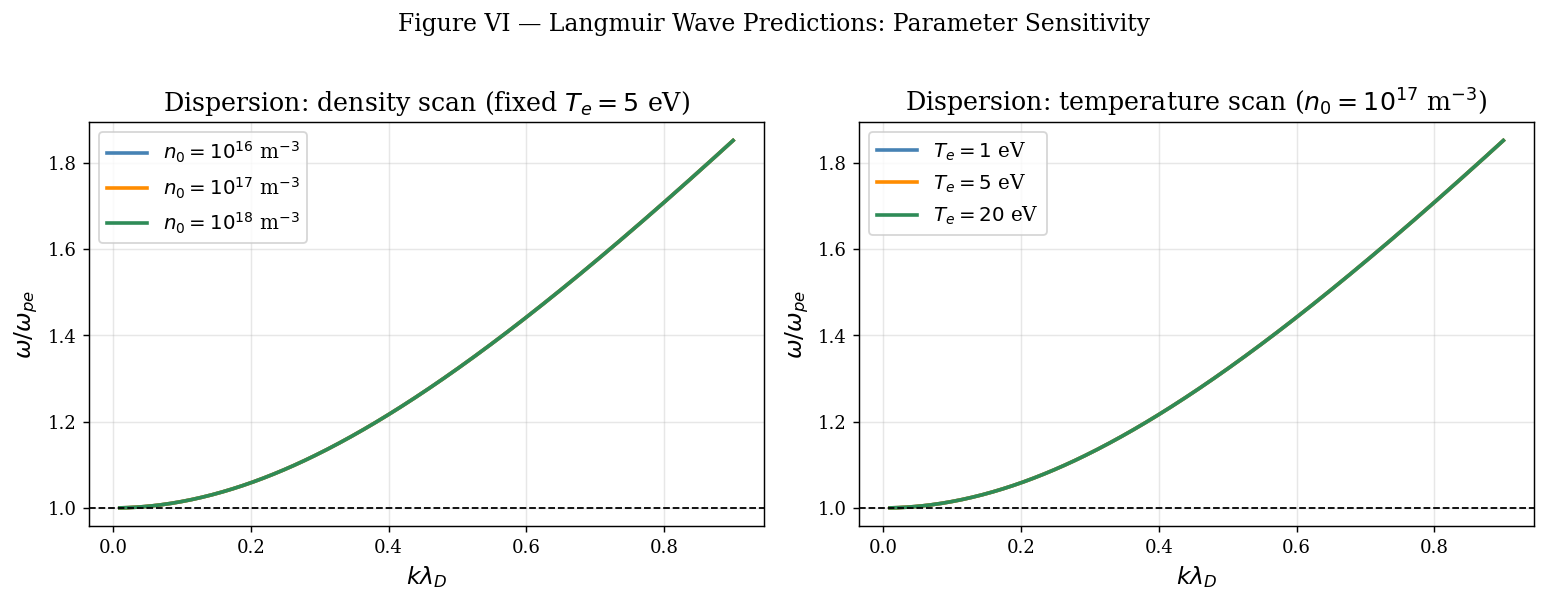

These curves are the theoretical predictions that Notebook II must reproduce numerically.


In [7]:
# ── §VI · Predicted observable: E-field power spectrum for Langmuir wave ─────
# Given plasma parameters, compute the expected spectral peak location
# This is the prediction the simulation notebook must reproduce.

def langmuir_spectrum_prediction(n0, Te, k_array):
    """
    Return predicted Langmuir wave frequency for each k.
    Uses Bohm–Gross dispersion relation.
    Parameters: n0 [m^-3], Te [K], k_array [m^-1]
    Returns: omega [rad/s]
    """
    eps0 = 8.854e-12; kB = 1.381e-23; e = 1.602e-19; me = 9.109e-31
    wpe  = np.sqrt(n0 * e**2 / (me * eps0))
    vTe  = np.sqrt(kB * Te / me)
    return np.sqrt(wpe**2 + 3 * k_array**2 * vTe**2), wpe, vTe

# ── Parameter scan ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

k_lD_plot = np.linspace(0.01, 0.9, 300)

# Density scan at fixed Te = 5 eV
Te_fixed = 5 * 11600
colors_n  = ['steelblue', 'darkorange', 'seagreen']
for n0_val, col in zip([1e16, 1e17, 1e18], colors_n):
    lD_val  = np.sqrt(eps0 * kB * Te_fixed / (n0_val * e**2))
    k_vals  = k_lD_plot / lD_val
    om, wpe_val, _ = langmuir_spectrum_prediction(n0_val, Te_fixed, k_vals)
    axes[0].plot(k_lD_plot, om/wpe_val, color=col, lw=2,
                 label=rf'$n_0 = 10^{{{int(np.log10(n0_val))}}}$ m$^{{-3}}$')
axes[0].axhline(1.0, ls='--', color='k', lw=1)
axes[0].set_xlabel(r'$k\lambda_D$'); axes[0].set_ylabel(r'$\omega/\omega_{pe}$')
axes[0].set_title('Dispersion: density scan (fixed $T_e=5$ eV)')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Temperature scan at fixed n0 = 1e17 m^-3
n0_fixed = 1e17
colors_T  = ['steelblue', 'darkorange', 'seagreen']
for Te_eV, col in zip([1, 5, 20], colors_T):
    Te_val  = Te_eV * 11600
    lD_val  = np.sqrt(eps0 * kB * Te_val / (n0_fixed * e**2))
    k_vals  = k_lD_plot / lD_val
    om, wpe_val, _ = langmuir_spectrum_prediction(n0_fixed, Te_val, k_vals)
    axes[1].plot(k_lD_plot, om/wpe_val, color=col, lw=2,
                 label=rf'$T_e = {Te_eV}$ eV')
axes[1].axhline(1.0, ls='--', color='k', lw=1)
axes[1].set_xlabel(r'$k\lambda_D$'); axes[1].set_ylabel(r'$\omega/\omega_{pe}$')
axes[1].set_title(r'Dispersion: temperature scan ($n_0 = 10^{17}$ m$^{-3}$)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Figure VI — Langmuir Wave Predictions: Parameter Sensitivity', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("These curves are the theoretical predictions that Notebook II must reproduce numerically.")


---
## Conclusion

This notebook has developed the complete theoretical chain connecting the microscopic description of a plasma to the macroscopic observable phenomenon of Langmuir oscillations:

1. **§0:** A plasma is defined by $\Lambda = n\lambda_D^3 \gg 1$; quasineutrality ($n_e = n_i = n_0$) is an essential prerequisite for both the existence of an equilibrium and the emergence of electrostatic restoring forces.

2. **§I–II:** The distribution function $f(\mathbf{r}, \mathbf{v}, t)$ is the fundamental object of kinetic theory. The Vlasov equation emerges from the Klimontovich micro-description in the mean-field (large-$\Lambda$) limit.

3. **§III (Liouville):** The incompressibility of phase-space flow — $\nabla_\mathbf{w}\cdot\dot{\mathbf{w}} = 0$ — follows from the Hamiltonian structure of the Lorentz force and implies $df/dt = 0$ along trajectories, exact kinetic entropy conservation, and the Vlasov equation as a direct corollary.

4. **§IV:** The Vlasov–Poisson system closes the self-consistent loop between the distribution function and the electrostatic field.

5. **§V (Linearisation):** Linearising about a Maxwellian equilibrium and Fourier-transforming yields the dielectric function $\varepsilon(\omega, k) = 0$, whose solution in the long-wavelength limit is the **Bohm–Gross dispersion relation** $\omega^2 = \omega_{pe}^2 + 3k^2v_{Te}^2$. The Landau-damped nature of these waves, arising from the resonance denominator $(\omega - kv)^{-1}$, is the signature kinetic prediction that distinguishes the Vlasov from all fluid theories.

6. **§VI:** The Semi-Lagrangian method is identified as the preferred numerical approach, with conservation of $\mathcal{N}$, $\mathcal{E}$, and $\mathcal{P}$ as primary sanity checks.

**The Computation Notebook (Report II)** implements a 1D1V Semi-Lagrangian Vlasov solver initialised with a small-amplitude sinusoidal density perturbation atop the Maxwellian equilibrium, and verifies the Bohm–Gross dispersion relation by comparing the numerically measured $\omega(k)$ to the theoretical curve derived in §V.

---

*End of Theory Notebook I.*
